In [ ]:
!pip install scipy numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
import os, json


In [ ]:
#Parámetros
FS       = 100      # Hz (confirmado del header OpenSignals)
VCC      = 3.3
ADC_BITS = 10
GAIN_EEG = 40000    # ganancia interna BITalino EEG

print('FS =', FS, 'Hz | Nyquist =', FS/2, 'Hz')


FS = 100 Hz | Nyquist = 50.0 Hz


In [ ]:
def load_bitalino(filepath):
    raw_vals, fs_file = [], FS
    with open(filepath, 'r') as f:
        for line in f:
            s = line.rstrip()
            if s.startswith('# {'):
                try:
                    meta = json.loads(s[2:])
                    key  = list(meta.keys())[0]
                    fs_file = int(meta[key].get('sampling rate', FS))
                except Exception:
                    pass
            elif s.startswith('#'):
                continue
            else:
                p = s.split('\t')
                if len(p) >= 6:
                    try: raw_vals.append(int(p[5]))
                    except ValueError: pass
    raw = np.array(raw_vals, dtype=float)
    uv  = ((raw / 2**ADC_BITS) - 0.5) * VCC / GAIN_EEG * 1e6
    t   = np.arange(len(uv)) / fs_file
    return t, uv, fs_file

In [ ]:
#Cargar archivos
import os

BASE = '/content/'  # carpeta donde Colab guarda los archivos subidos directo a la sesión

archivos = {
    "ritmo_basal_1": "1_ritmo_basal_1.txt",
    "apertura_ojos_vision_fija": "2_apertura_ojos_vision_fija.txt",
    "ritmo_basal_2_30s": "3_ritmo_basal 2_(30seg).txt",
    "parpadeo_masticacion": "4_parpadeo_masticacion.txt",
    "musica_relajante": "6_musica_relajante.txt",
    "musica_estresante": "7_musica_estresante.txt",
}

def fp(nombre):
    return os.path.join(BASE, archivos[nombre])

In [ ]:
#Filtro pasa banda (0.5–40 Hz),

def bandpass_filter(sig, lo=0.5, hi=40.0, fs=FS, order=4):
    nyq = fs / 2.0
    hi_eff = min(hi, nyq - 0.5)   # evita salirse de Nyquist
    if hi_eff != hi:
        print(f'Límite superior ajustado de {hi} Hz a {hi_eff:.2f} Hz (Nyquist = {nyq} Hz)')
    b, a = butter(order, [lo/nyq, hi_eff/nyq], btype='band')
    return filtfilt(b, a, sig)

#filtro notch (50/60 Hz).
def notch_filter(sig, freq, Q=30, fs=FS):
    if freq >= fs/2: return sig
    b, a = iirnotch(freq/(fs/2), Q)
    return filtfilt(b, a, sig)


def apply_filters(sig, fs=FS, notch_freqs=(50.0, 60.0)):
    out = bandpass_filter(sig, lo=0.5, hi=40.0, fs=fs)
    for f0 in notch_freqs:
        out = notch_filter(out, f0, fs=fs)
    return out


In [ ]:
# Filtrar todas las señales EEG

signals = {}   # guarda t, raw y filtrado por archivo

for n, label in archivos.items():
    filepath = fp(n)
    if not os.path.exists(filepath):
        print(f'No encontrado: {filepath}')
        continue

    print(f'\n{"="*60}\n  {n} — {label}\n{"="*60}')

    t, raw, fs = load_bitalino(filepath)
    flt = apply_filters(raw, fs=fs)   # usa el fs real de ESTE archivo, no el FS global

    signals[n] = dict(t=t, raw=raw, flt=flt, fs=fs, label=label)
    print(f'  Duración: {t[-1]:.1f}s | Muestras: {len(t)} | FS: {fs} Hz')


  ritmo_basal_1 — 1_ritmo_basal_1.txt
  Duración: 61.9s | Muestras: 6195 | FS: 100 Hz

  apertura_ojos_vision_fija — 2_apertura_ojos_vision_fija.txt
  Duración: 62.2s | Muestras: 6225 | FS: 100 Hz

  ritmo_basal_2_30s — 3_ritmo_basal 2_(30seg).txt
  Duración: 35.5s | Muestras: 3555 | FS: 100 Hz

  parpadeo_masticacion — 4_parpadeo_masticacion.txt
  Duración: 61.9s | Muestras: 6195 | FS: 100 Hz

  musica_relajante — 6_musica_relajante.txt
  Duración: 64.8s | Muestras: 6480 | FS: 100 Hz

  musica_estresante — 7_musica_estresante.txt
  Duración: 62.5s | Muestras: 6255 | FS: 100 Hz


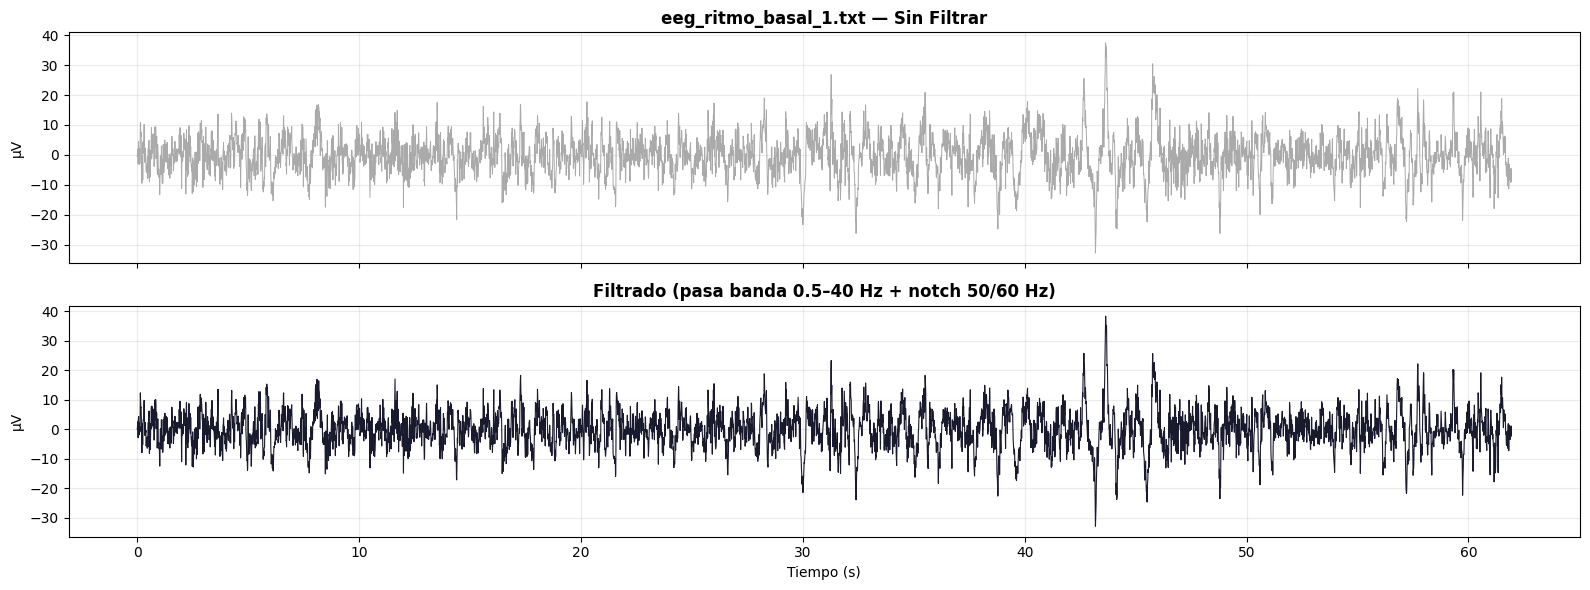

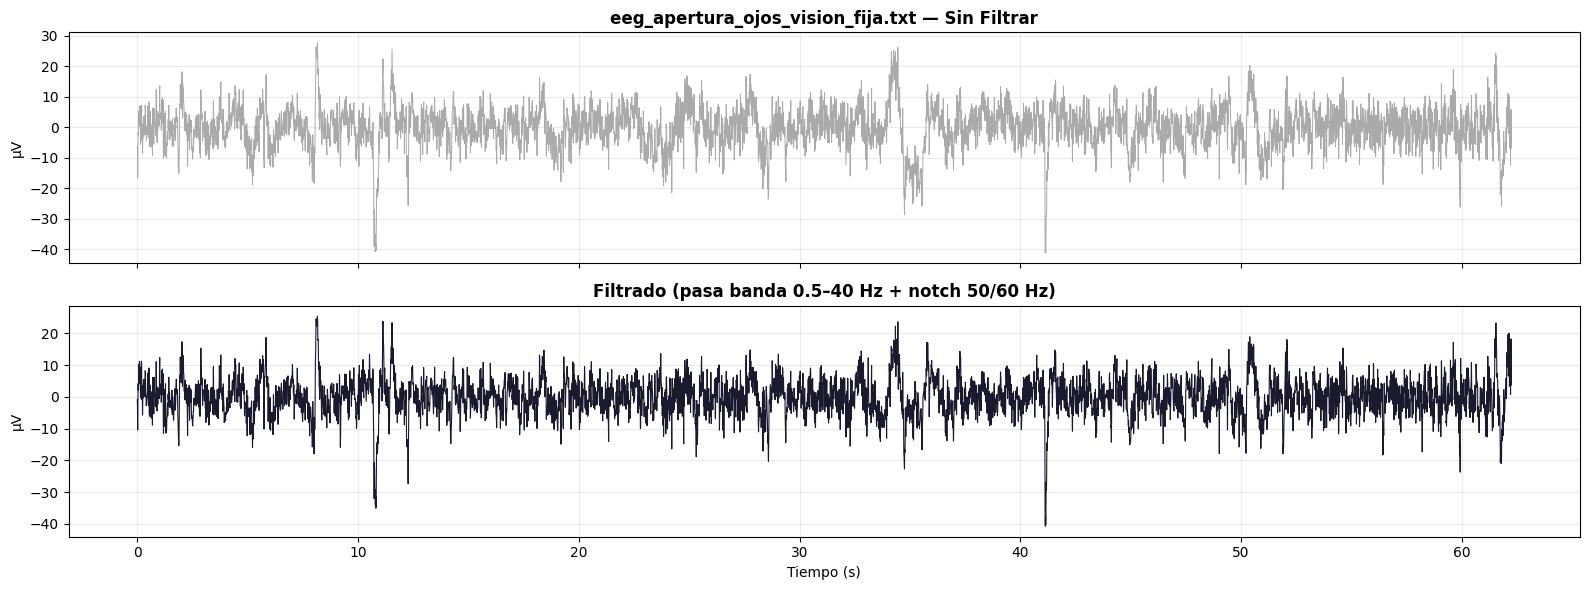

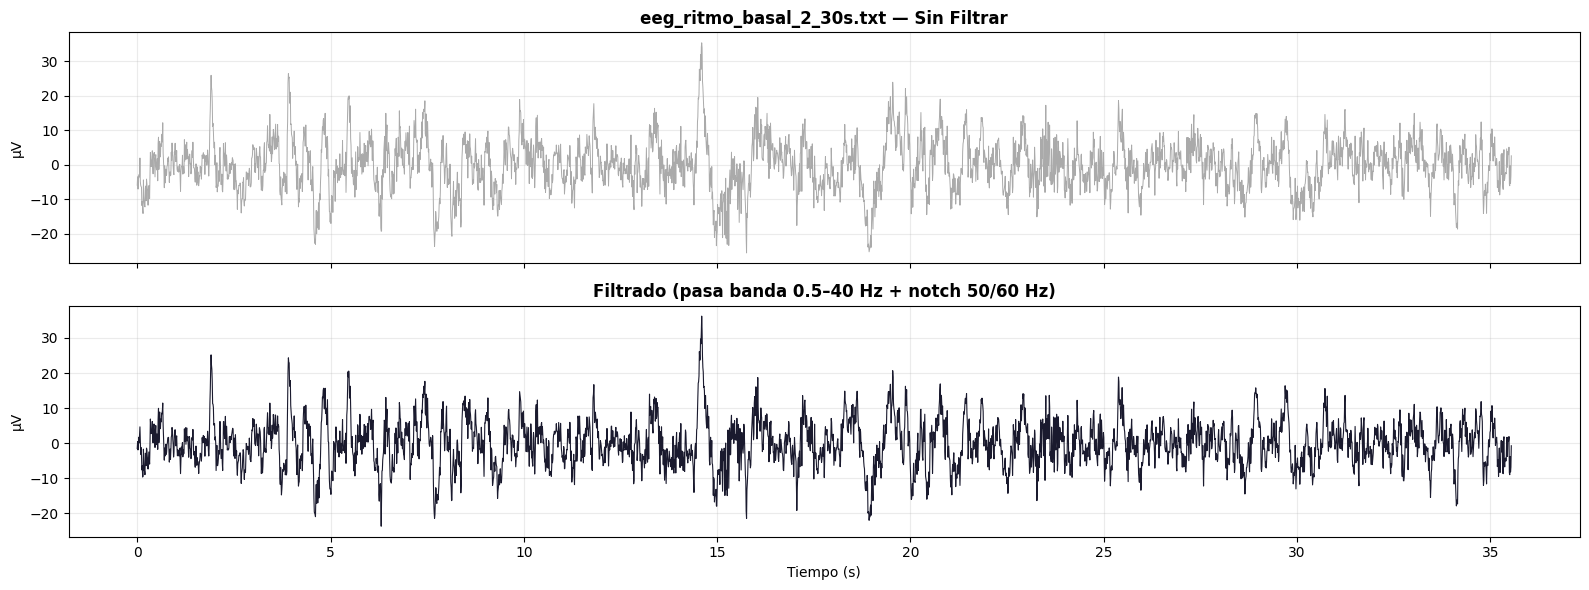

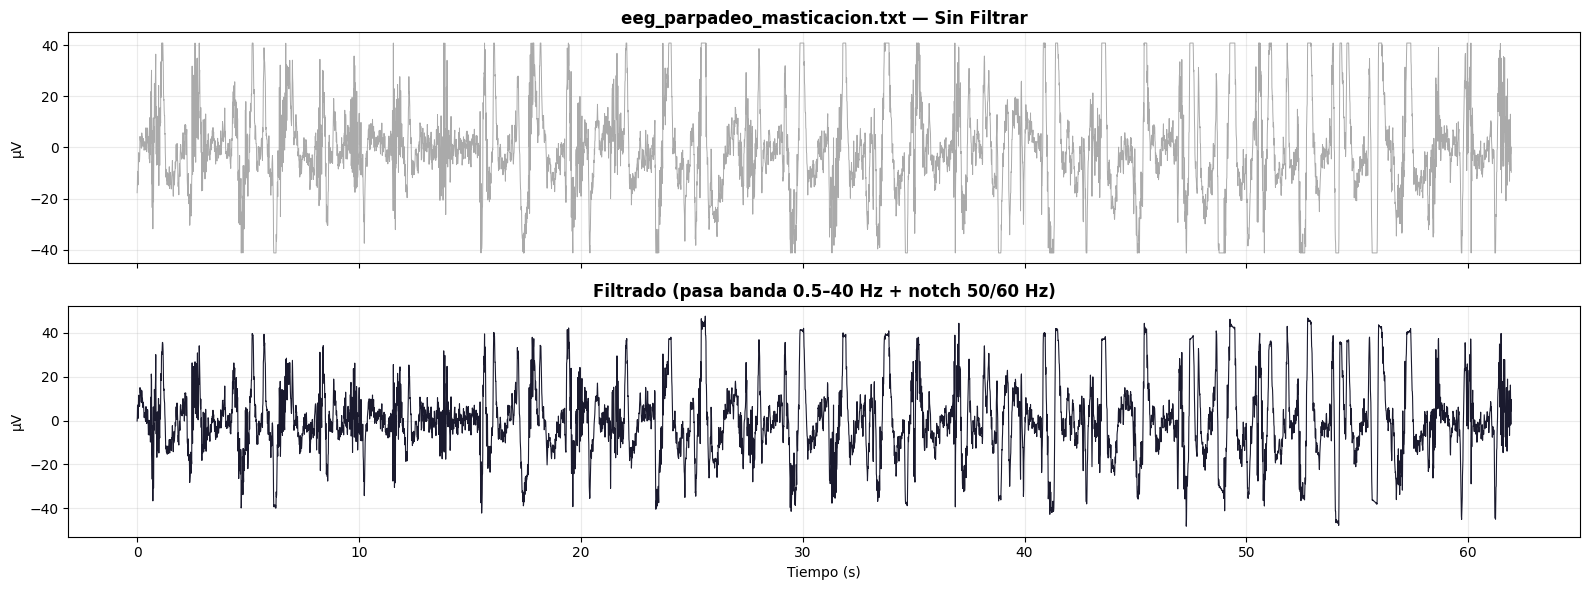

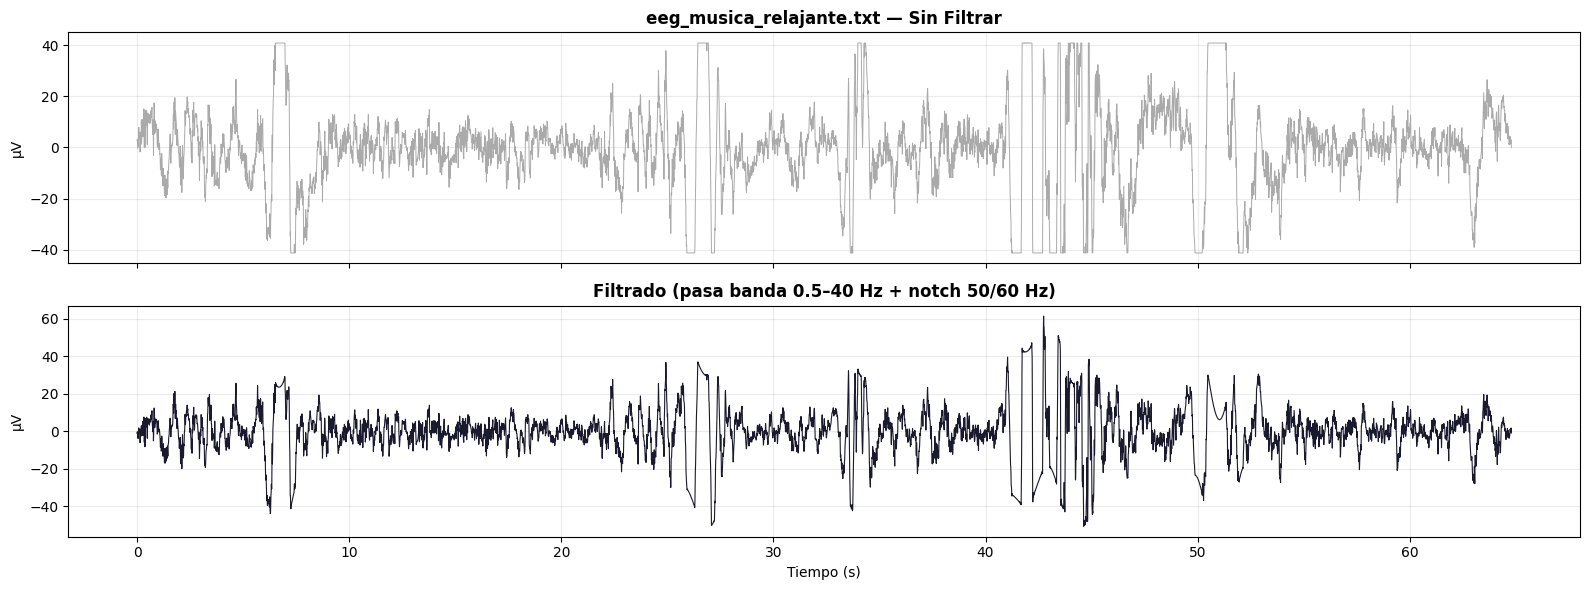

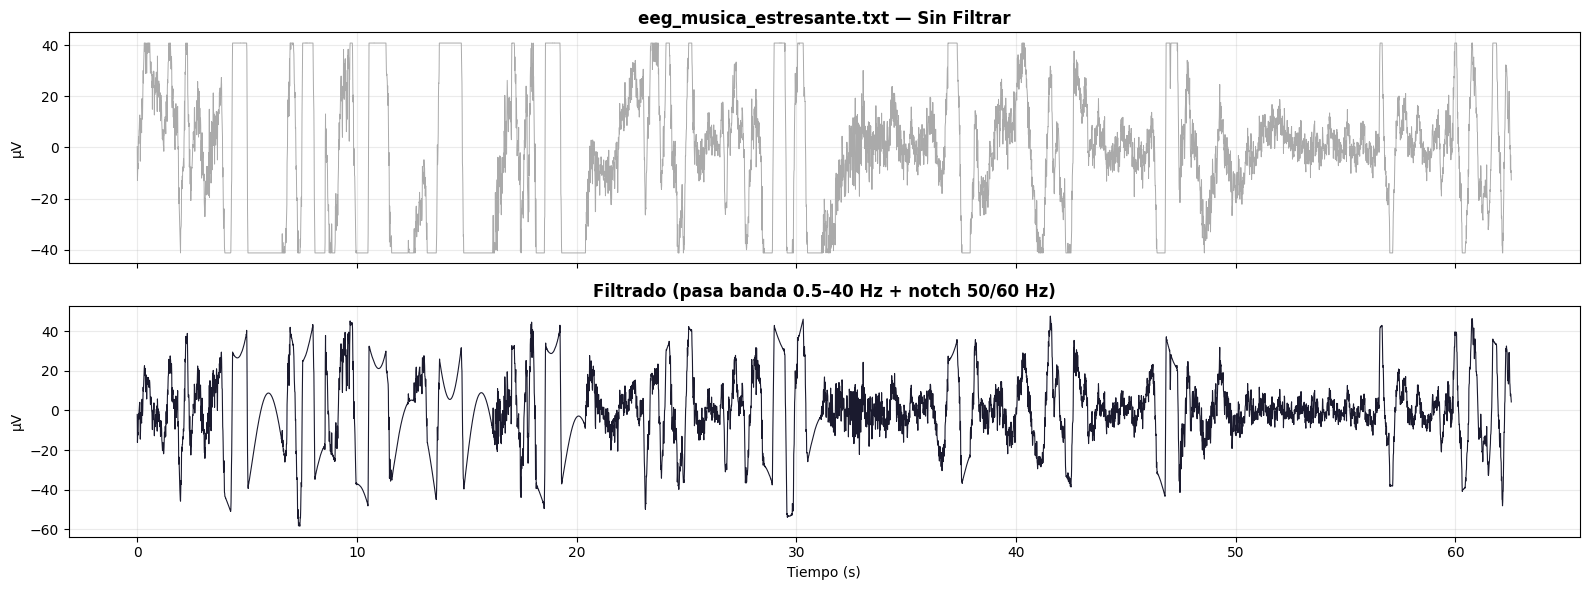

In [ ]:
for n, d in signals.items():
    fig, ax = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
    ax[0].plot(d['t'], d['raw'], color='#aaa', lw=0.7)
    ax[0].set_ylabel('µV'); ax[0].set_title(f"eeg_{n}.txt — Sin Filtrar", fontweight='bold')
    ax[0].grid(alpha=0.25)

    ax[1].plot(d['t'], d['flt'], color='#1a1a2e', lw=0.8)
    ax[1].set_xlabel('Tiempo (s)'); ax[1].set_ylabel('µV')
    ax[1].set_title('Filtrado (pasa banda 0.5–40 Hz + notch 50/60 Hz)', fontweight='bold')
    ax[1].grid(alpha=0.25)

    plt.tight_layout(); plt.show()


Implementar ICA usando Python (por ejemplo con MNE-Python o Scikit-learn).


In [ ]:
# Implementamos ICA

!pip install scipy numpy matplotlib EMD-signal scikit-learn -q

from PyEMD import EMD
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.


Graficar e identificar las componentes relacionadas con artefactos

In [ ]:
def emd_ica_decompose(sig, max_imfs=8, random_state=97):
    emd = EMD()
    imfs = emd.emd(sig, max_imf=max_imfs)
    n_imfs = imfs.shape[0]
    if n_imfs < 2:
        raise ValueError(f'Solo se obtuvieron {n_imfs} IMF(s); se necesitan al menos 2 para ICA.')

    ica = FastICA(n_components=n_imfs, random_state=random_state, max_iter=1000)
    X = imfs.T
    S = ica.fit_transform(X)
    return imfs, S, ica

def reconstruct_clean(S, ica, exclude):
    S_clean = S.copy()
    if exclude:
        S_clean[:, exclude] = 0.0
    X_clean = ica.inverse_transform(S_clean)
    return X_clean.sum(axis=1)

Reconstruir la señal EEG eliminando dichas componentes.


Procesando ritmo_basal_1 — 1_ritmo_basal_1.txt...
  Componentes a excluir: []
  No hay componentes con |curtosis| > 5.
  Curtosis por componente:
    IC0:   0.956
    IC1:   1.141
    IC2:  -0.102
    IC3:   2.991
    IC4:   2.159
    IC5:   1.954
    IC6:   0.282
    IC7:   1.905
    IC8:   3.327

Procesando apertura_ojos_vision_fija — 2_apertura_ojos_vision_fija.txt...
  Componentes a excluir: [2]


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


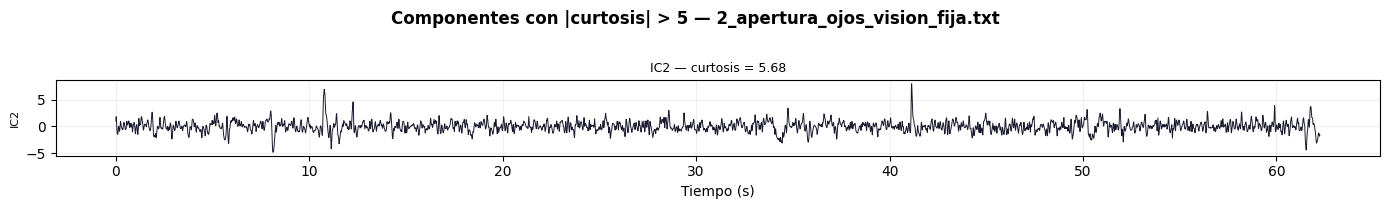

  Curtosis por componente:
    IC0:   4.538
    IC1:   0.746
    IC2:   5.682  <- candidato a artefacto
    IC3:  -0.877
    IC4:   4.426
    IC5:   1.932
    IC6:   0.295
    IC7:   4.072
    IC8:  -0.473

Procesando ritmo_basal_2_30s — 3_ritmo_basal 2_(30seg).txt...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


  Componentes a excluir: []
  No hay componentes con |curtosis| > 5.
  Curtosis por componente:
    IC0:   1.098
    IC1:  -0.940
    IC2:  -0.255
    IC3:   0.860
    IC4:   1.401
    IC5:  -0.172
    IC6:   1.211
    IC7:   2.140
    IC8:  -0.280

Procesando parpadeo_masticacion — 4_parpadeo_masticacion.txt...
  Componentes a excluir: []
  No hay componentes con |curtosis| > 5.
  Curtosis por componente:
    IC0:   0.394
    IC1:  -0.851
    IC2:   4.011
    IC3:   2.581
    IC4:   1.313
    IC5:   1.896
    IC6:   4.644
    IC7:   0.784
    IC8:   4.565

Procesando musica_relajante — 6_musica_relajante.txt...
  Componentes a excluir: [0, 1, 4, 6, 7]


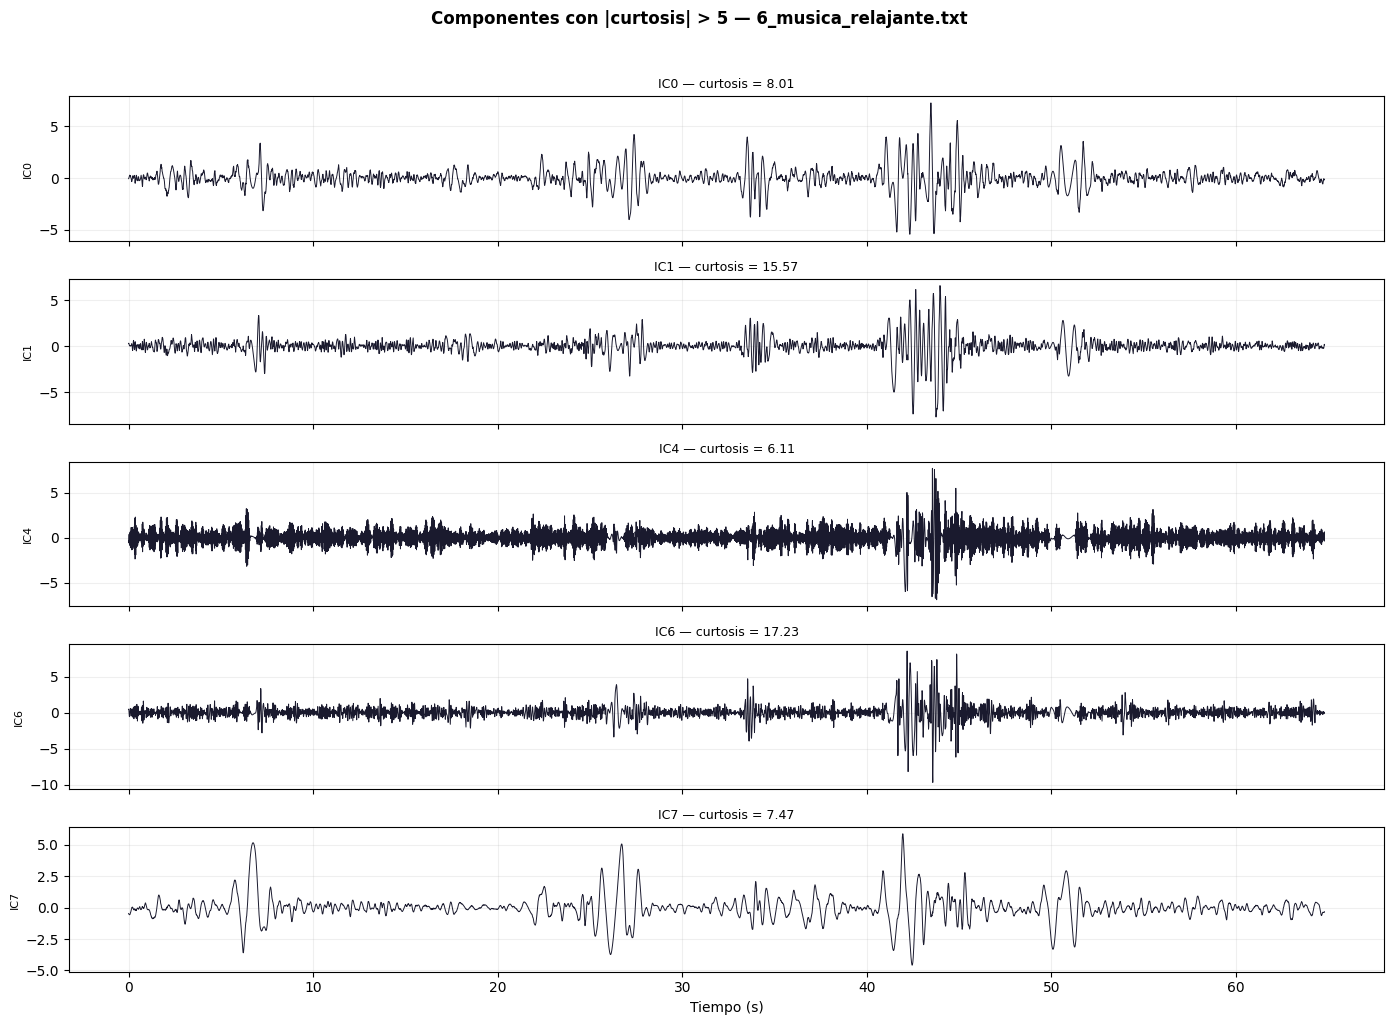

  Curtosis por componente:
    IC0:   8.010  <- candidato a artefacto
    IC1:  15.571  <- candidato a artefacto
    IC2:   1.708
    IC3:   0.964
    IC4:   6.111  <- candidato a artefacto
    IC5:   1.692
    IC6:  17.226  <- candidato a artefacto
    IC7:   7.470  <- candidato a artefacto
    IC8:   2.382

Procesando musica_estresante — 7_musica_estresante.txt...
  Componentes a excluir: [0, 2, 4, 5, 8]


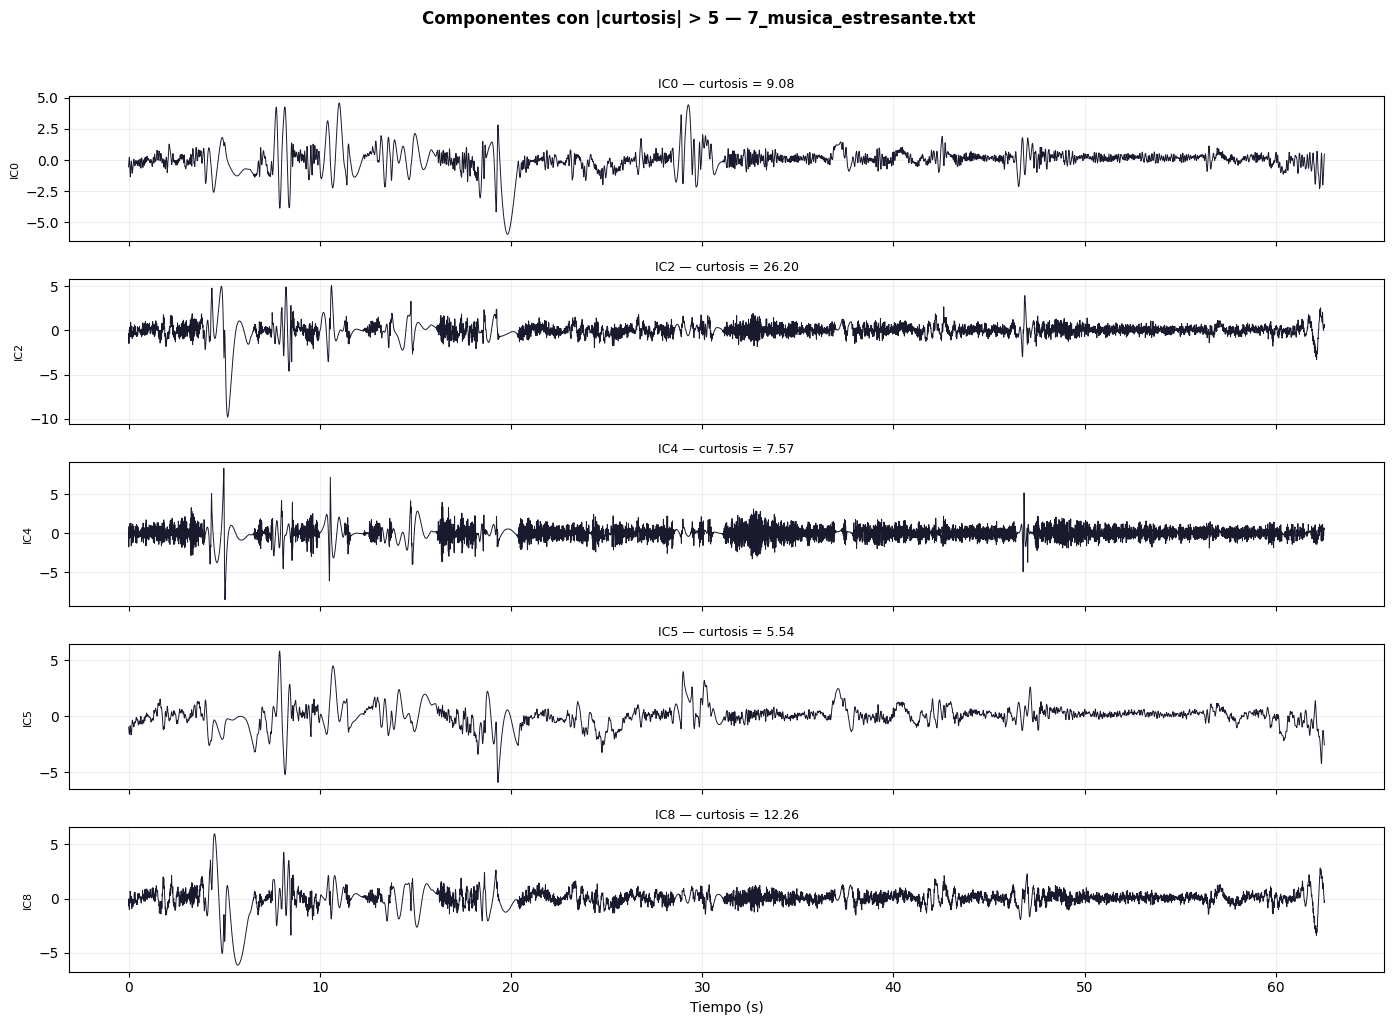

  Curtosis por componente:
    IC0:   9.082  <- candidato a artefacto
    IC1:   4.392
    IC2:  26.204  <- candidato a artefacto
    IC3:   1.419
    IC4:   7.573  <- candidato a artefacto
    IC5:   5.536  <- candidato a artefacto
    IC6:   1.971
    IC7:   1.247
    IC8:  12.257  <- candidato a artefacto


In [ ]:
for label_ica, d in signals.items():
    print(f"\nProcesando {label_ica} — {d['label']}...")

    sig, fs, t = d['flt'], d['fs'], d['t']

    try:
        imfs, S, ica = emd_ica_decompose(sig, max_imfs=8)
    except ValueError as e:
        print(f"  Saltado: {e}")
        continue

    kurt = [kurtosis(S[:, i]) for i in range(S.shape[1])]
    exclude_components = [i for i, k in enumerate(kurt) if abs(k) > 5]
    print("  Componentes a excluir:", exclude_components)

    sig_ica_clean = reconstruct_clean(S, ica, exclude_components)

    signals[label_ica]["ica_clean"] = sig_ica_clean
    signals[label_ica]["ica_kurtosis"] = kurt
    signals[label_ica]["ica_excluded"] = exclude_components

    if exclude_components:
        fig, axes = plt.subplots(len(exclude_components), 1,
                                  figsize=(14, 2 * len(exclude_components)), sharex=True)
        if len(exclude_components) == 1:
            axes = [axes]
        for ax, i in zip(axes, exclude_components):
            ax.plot(t, S[:, i], lw=0.7, color="#1a1a2e")
            ax.set_ylabel(f"IC{i}", fontsize=8)
            ax.set_title(f"IC{i} — curtosis = {kurt[i]:.2f}", fontsize=9)
            ax.grid(alpha=0.2)
        axes[-1].set_xlabel("Tiempo (s)")
        fig.suptitle(f"Componentes con |curtosis| > 5 — {d['label']}", y=1.02, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("  No hay componentes con |curtosis| > 5.")

    print("  Curtosis por componente:")
    for i, k in enumerate(kurt):
        flag = "  <- candidato a artefacto" if abs(k) > 5 else ""
        print(f"    IC{i}: {k:7.3f}{flag}")

Comparación: señal original vs señal reconstruida tras eliminar ICs con |curtosis| > 5


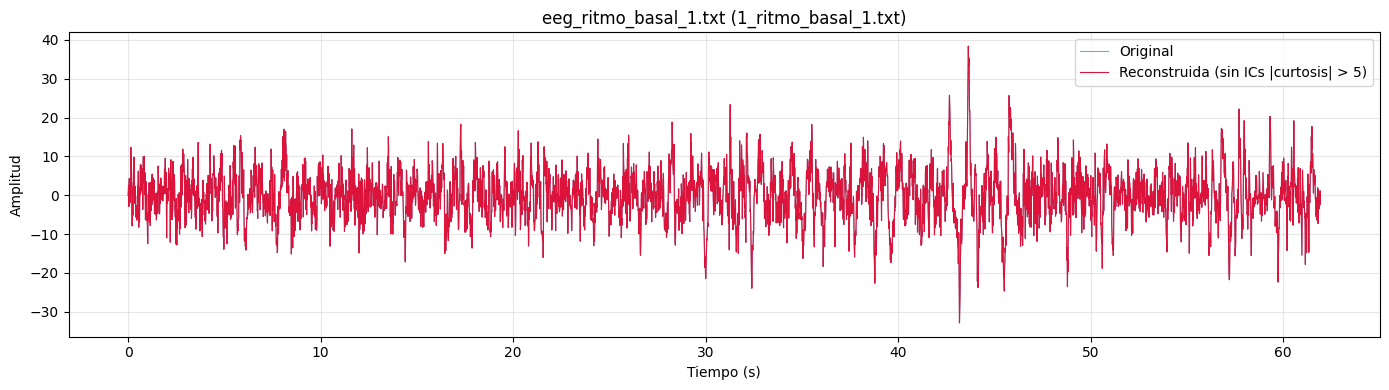

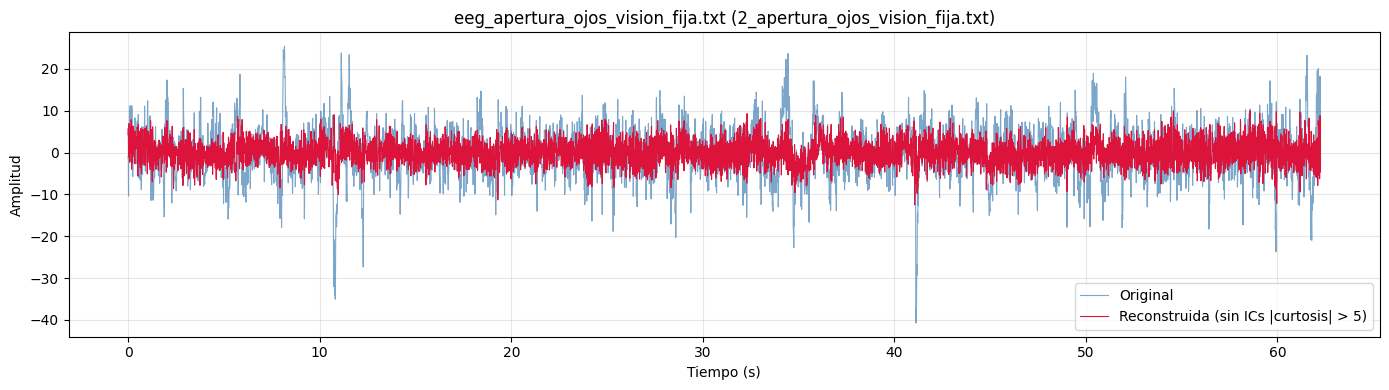

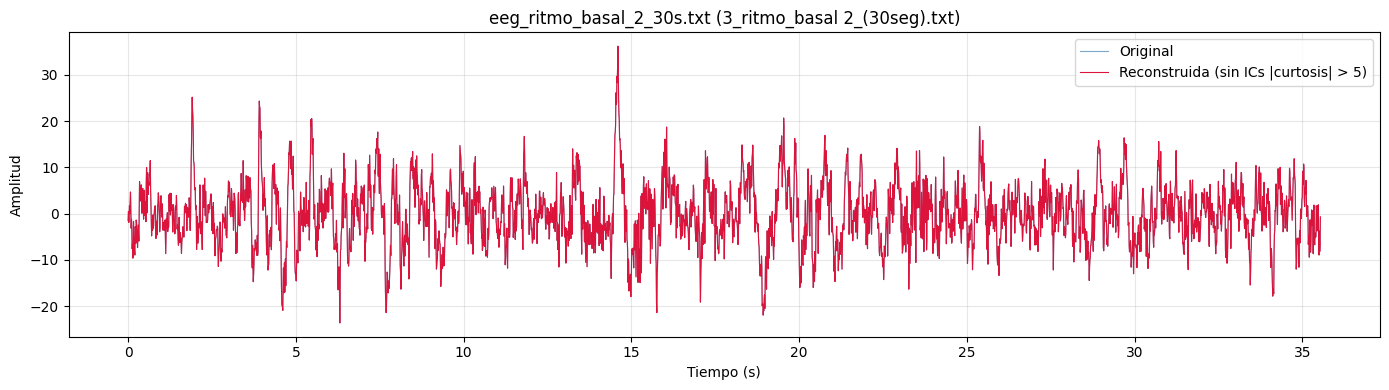

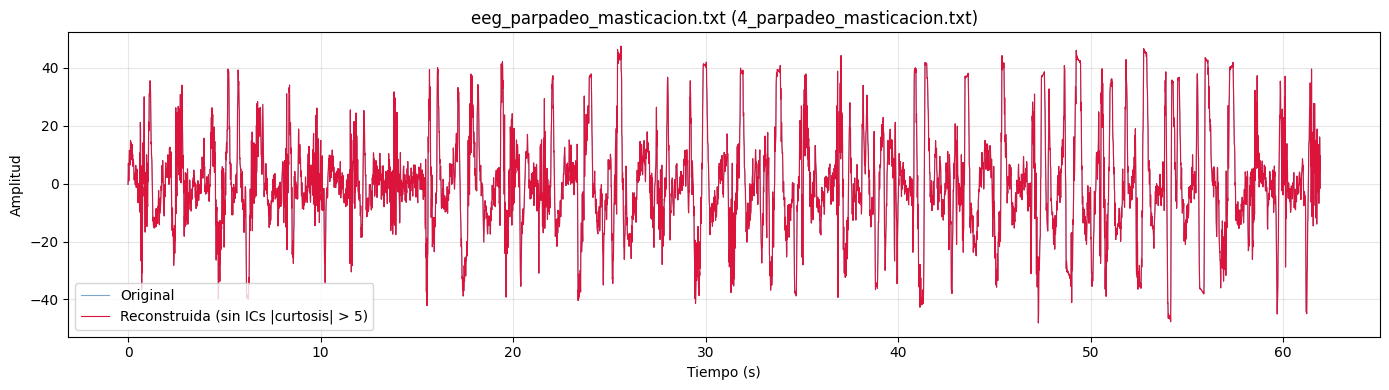

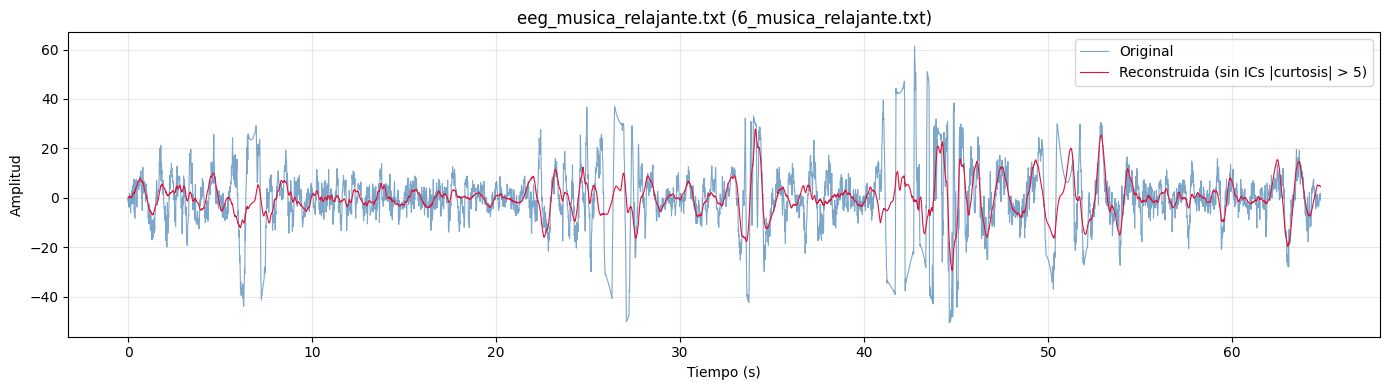

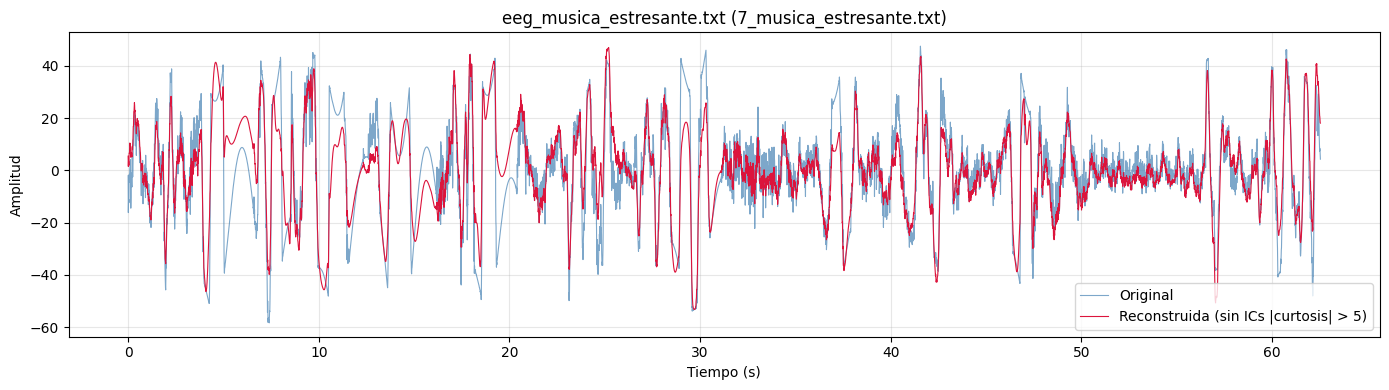

In [ ]:

for label_ica, d in signals.items():

    t = d["t"]
    sig_original = d["flt"]
    sig_clean = d["ica_clean"]

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(
        t, sig_original,
        label="Original",
        color="steelblue",
        lw=0.8,
        alpha=0.7
    )

    ax.plot(
        t, sig_clean,
        label="Reconstruida (sin ICs |curtosis| > 5)",
        color="crimson",
        lw=0.8
    )

    ax.set_title(f"eeg_{label_ica}.txt ({d['label']})")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()